# ============================================================
# 224x224 patch experiment
# Exploratory experiment to test whether larger spatial context
# improves classification performance.
# This experiment was not used as the main final pipeline due to
# unstable validation and test behaviour.
# ============================================================

In [7]:
import os
from pathlib import Path
from functools import lru_cache
from pprint import pprint

import lightning as pl
import numpy as np
import torch
import yaml

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt

In [8]:
# ============================================================
# Path configuration
# ============================================================

# Base project directory
BASE_DIR = Path("/p/scratch/training2600/ripp1/Project")

# Directory containing the TerraTorch-ready dataset
# Adjust this if your 224x224 dataset is stored elsewhere
TERRATORCH_DATA_DIR = BASE_DIR / "training_data_224"

TRAIN_DIR = TERRATORCH_DATA_DIR / "train"
VAL_DIR   = TERRATORCH_DATA_DIR / "val"
TEST_DIR  = TERRATORCH_DATA_DIR / "test"

# Directory for outputs (logs, checkpoints, figures)
OUTPUT_DIR = BASE_DIR / "terratorch_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Basic checks
assert TERRATORCH_DATA_DIR.exists(), f"Dataset path not found: {TERRATORCH_DATA_DIR}"
assert TRAIN_DIR.exists(), f"Train path not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation path not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test path not found: {TEST_DIR}"

print("Using TerraTorch data from:")
print(f"  Train: {TRAIN_DIR}")
print(f"  Val:   {VAL_DIR}")
print(f"  Test:  {TEST_DIR}")
print(f"  Output: {OUTPUT_DIR}")

Using TerraTorch data from:
  Train: /p/scratch/training2600/ripp1/Project/training_data_224/train
  Val:   /p/scratch/training2600/ripp1/Project/training_data_224/val
  Test:  /p/scratch/training2600/ripp1/Project/training_data_224/test
  Output: /p/scratch/training2600/ripp1/Project/terratorch_outputs


In [9]:
# ============================================================
# Utils
# ============================================================

def load_split_data(split_dir, split_name):
    """
    Load patches and labels for one split.

    Parameters:
    -----------
    split_dir : Path
        Directory of the split
    split_name : str
        Name of the split ("train", "val", or "test")

    Returns:
    --------
    X : np.ndarray
        Patch data
    y : np.ndarray
        Labels
    """
    patches_path = split_dir / f"patches_{split_name}.npz"
    labels_path = split_dir / f"labels_{split_name}.npy"

    X = np.load(patches_path)["patches"]
    y = np.load(labels_path)

    return X, y


def get_class_distribution(labels):
    """
    Compute class distribution from a label array.
    """
    unique, counts = np.unique(labels, return_counts=True)
    return {
        int(k): int(v)
        for k, v in sorted(zip(unique, counts), key=lambda x: -x[1])
    }

In [10]:
# ============================================================
# Quick data check
# ============================================================

X_train, y_train = load_split_data(TRAIN_DIR, "train")
X_val, y_val = load_split_data(VAL_DIR, "val")
X_test, y_test = load_split_data(TEST_DIR, "test")

print("Train:", X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print("Val:  ", X_val.shape, y_val.shape, X_val.dtype, y_val.dtype)
print("Test: ", X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

print("\nTrain class distribution:")
print(get_class_distribution(y_train))

Train: (3406, 224, 224, 4) (3406,) float32 uint8
Val:   (1000, 224, 224, 4) (1000,) float32 uint8
Test:  (1000, 224, 224, 4) (1000,) float32 uint8

Train class distribution:
{12: 1224, 23: 744, 18: 422, 2: 360, 24: 181, 15: 153, 25: 85, 3: 74, 16: 32, 1: 27, 20: 21, 11: 18, 40: 13, 6: 12, 21: 10, 7: 6, 29: 6, 41: 6, 4: 5, 8: 2, 10: 2, 26: 2, 35: 1}


In [11]:
# ============================================================
# Filter rare classes and create label mapping
# ============================================================

MIN_SAMPLES_PER_CLASS = 10

train_dist = get_class_distribution(y_train)

# Keep only classes with at least MIN_SAMPLES_PER_CLASS samples in train
kept_classes = sorted([cls for cls, count in train_dist.items() if count >= MIN_SAMPLES_PER_CLASS])
removed_classes = sorted([cls for cls, count in train_dist.items() if count < MIN_SAMPLES_PER_CLASS])

print(f"Keeping {len(kept_classes)} classes:")
print(kept_classes)

print(f"\nRemoving {len(removed_classes)} rare classes:")
print(removed_classes)

def filter_by_kept_classes(X, y, kept_classes):
    kept_classes = np.array(kept_classes)
    mask = np.isin(y, kept_classes)
    return X[mask], y[mask]

# Filter all splits using the classes defined from the training split
X_train_f, y_train_f = filter_by_kept_classes(X_train, y_train, kept_classes)
X_val_f, y_val_f     = filter_by_kept_classes(X_val, y_val, kept_classes)
X_test_f, y_test_f   = filter_by_kept_classes(X_test, y_test, kept_classes)

print("\nFiltered dataset sizes:")
print("  Train:", X_train_f.shape, y_train_f.shape)
print("  Val:  ", X_val_f.shape, y_val_f.shape)
print("  Test: ", X_test_f.shape, y_test_f.shape)

# Create contiguous label mapping
label_to_idx = {int(lbl): i for i, lbl in enumerate(kept_classes)}
idx_to_label = {i: int(lbl) for i, lbl in enumerate(kept_classes)}

print("\nLabel mapping (original -> index):")
for orig, idx in label_to_idx.items():
    print(f"  {orig:2d} -> {idx}")

# Remap labels
y_train_m = np.array([label_to_idx[int(lbl)] for lbl in y_train_f], dtype=np.int64)
y_val_m   = np.array([label_to_idx[int(lbl)] for lbl in y_val_f], dtype=np.int64)
y_test_m  = np.array([label_to_idx[int(lbl)] for lbl in y_test_f], dtype=np.int64)

print(f"\nNumber of final classes: {len(kept_classes)}")

Keeping 15 classes:
[1, 2, 3, 6, 11, 12, 15, 16, 18, 20, 21, 23, 24, 25, 40]

Removing 8 rare classes:
[4, 7, 8, 10, 26, 29, 35, 41]

Filtered dataset sizes:
  Train: (3376, 224, 224, 4) (3376,)
  Val:   (994, 224, 224, 4) (994,)
  Test:  (994, 224, 224, 4) (994,)

Label mapping (original -> index):
   1 -> 0
   2 -> 1
   3 -> 2
   6 -> 3
  11 -> 4
  12 -> 5
  15 -> 6
  16 -> 7
  18 -> 8
  20 -> 9
  21 -> 10
  23 -> 11
  24 -> 12
  25 -> 13
  40 -> 14

Number of final classes: 15


In [12]:
# ============================================================
# Dataset
# ============================================================

class CorineDataset(Dataset):
    """
    Dataset for Sentinel-2 224x224 patches and remapped CORINE labels.

    Parameters:
    -----------
    data : np.ndarray (N, H, W, C)
    labels : np.ndarray (N,)
    """

    def __init__(self, data, labels):
        super().__init__()

        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

        # Convert from (H, W, C) to (C, H, W)
        self.data = self.data.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        return x, y

In [13]:
# ============================================================
# Lightning DataModule
# ============================================================

class CorineDataModule(pl.LightningDataModule):
    """
    Lightning DataModule for 224x224 Sentinel-2 / CORINE classification.
    """

    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = CorineDataset(self.X_train, self.y_train)
        self.val_dataset = CorineDataset(self.X_val, self.y_val)
        self.test_dataset = CorineDataset(self.X_test, self.y_test)

        self.train_labels = torch.tensor(self.y_train, dtype=torch.long)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

In [14]:
# ============================================================
# Create DataModule
# ============================================================

BATCH_SIZE = 32

datamodule = CorineDataModule(
    X_train_f, y_train_m,
    X_val_f, y_val_m,
    X_test_f, y_test_m,
    batch_size=BATCH_SIZE,
)

datamodule.setup()

print("Datasets loaded successfully:")
print(f"  Train samples: {len(datamodule.train_dataset)}")
print(f"  Val samples:   {len(datamodule.val_dataset)}")
print(f"  Test samples:  {len(datamodule.test_dataset)}")

Datasets loaded successfully:
  Train samples: 3376
  Val samples:   994
  Test samples:  994


In [15]:
# ============================================================
# Quick DataLoader sanity check
# ============================================================

train_loader = datamodule.train_dataloader()
xb, yb = next(iter(train_loader))

print("Quick data check:")
print(f"  Batch X shape: {xb.shape} (dtype={xb.dtype})")
print(f"  Batch y shape: {yb.shape} (dtype={yb.dtype})")
print(f"  y range:       [{yb.min().item()}, {yb.max().item()}]")
print(f"  Unique classes in batch: {sorted(torch.unique(yb).tolist())}")

Quick data check:
  Batch X shape: torch.Size([32, 4, 224, 224]) (dtype=torch.float32)
  Batch y shape: torch.Size([32]) (dtype=torch.int64)
  y range:       [1, 13]
  Unique classes in batch: [1, 5, 6, 7, 8, 11, 13]


In [16]:
# ============================================================
# Model
# ============================================================

class ConvNet224(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-4):
        super().__init__()

        self.lr = lr
        self.num_classes = num_classes

        # Feature extractor
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(4, 32, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 224 → 112

            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 112 → 56

            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 56 → 28

            torch.nn.Conv2d(128, 256, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),  # 28 → 14
        )

        # Classifier
        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(256 * 14 * 14, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(256, num_classes),
        )

        self.loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

In [17]:
# ============================================================
# Create model
# ============================================================

num_classes = len(np.unique(y_train_m))

model = ConvNet224(
    num_classes=num_classes,
    lr=1e-4
)

print("Model created successfully.")
print(f"  Number of classes: {num_classes}")

Model created successfully.
  Number of classes: 15


In [18]:
# ============================================================
# Training
# ============================================================

MAX_EPOCHS = 30

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    enable_progress_bar=True,
)

print("Starting training...")
trainer.fit(model, datamodule=datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Starting training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential       │  389 K │ train │     0 │
│ 1 │ classifier │ Sequential       │ 12.8 M │ train │     0 │
│ 2 │ loss_fn    │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 13.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.2 M                                                                                               
Total estimated model params size (MB): 52                                                                         
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


Output()

/p/project1/training2600/ripp1/envs/ml_eo_course/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.p
y:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


In [19]:
# ============================================================
# Testing
# ============================================================

print("Starting test evaluation...")
trainer.test(model, datamodule=datamodule)

Starting test evaluation...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]
SLURM auto-requeueing enabled. Setting signal handlers.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8812877535820007     │
│         test_loss         │    0.9158735275268555     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.9158735275268555, 'test_acc': 0.8812877535820007}]

In [20]:
# ============================================================
# Diagnostics
# ============================================================

def collect_preds_targets(model, dataloader):
    model.eval()
    device = next(model.parameters()).device

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = yb.cpu().numpy()

            preds_all.append(preds)
            targets_all.append(targets)

    y_pred = np.concatenate(preds_all).astype(np.int64)
    y_true = np.concatenate(targets_all).astype(np.int64)

    return y_true, y_pred


def compute_confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1

    return labels, cm


def compute_imbalanced_metrics(cm):
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    balanced_acc = recall.mean()
    macro_f1 = f1.mean()

    return overall_acc, balanced_acc, macro_f1, recall, precision, f1


def evaluate_split(model, dataloader, split_name):
    y_true, y_pred = collect_preds_targets(model, dataloader)
    labels, cm = compute_confusion_matrix(y_true, y_pred)

    overall_acc, balanced_acc, macro_f1, recall, precision, f1 = compute_imbalanced_metrics(cm)

    vals, cnts = np.unique(y_true, return_counts=True)
    majority_baseline = cnts.max() / cnts.sum()

    print("\n" + "=" * 70)
    print(f"{split_name.upper()} DIAGNOSTICS")
    print("=" * 70)
    print(f"Majority-class baseline acc: {majority_baseline:.4f}")
    print(f"Overall accuracy:            {overall_acc:.4f}")
    print(f"Balanced accuracy:           {balanced_acc:.4f}")
    print(f"Macro-F1:                    {macro_f1:.4f}")

    return {
        "overall_acc": overall_acc,
        "balanced_acc": balanced_acc,
        "macro_f1": macro_f1,
        "confusion_matrix": cm,
    }


val_results = evaluate_split(model, datamodule.val_dataloader(), "validation")
test_results = evaluate_split(model, datamodule.test_dataloader(), "test")


VALIDATION DIAGNOSTICS
Majority-class baseline acc: 0.3340
Overall accuracy:            0.3139
Balanced accuracy:           0.2220
Macro-F1:                    0.2268

TEST DIAGNOSTICS
Majority-class baseline acc: 0.3360
Overall accuracy:            0.8813
Balanced accuracy:           0.6968
Macro-F1:                    0.6869


In [21]:
def evaluate_model(model, dataloader, name="model"):
    y_true, y_pred = collect_preds_targets(model, dataloader)
    labels, cm = compute_confusion_matrix(y_true, y_pred)

    overall_acc, balanced_acc, macro_f1, recall, precision, f1 = compute_imbalanced_metrics(cm)

    print("\n" + "=" * 70)
    print(f"{name.upper()} RESULTS")
    print("=" * 70)
    print(f"Overall accuracy:  {overall_acc:.4f}")
    print(f"Balanced accuracy:{balanced_acc:.4f}")
    print(f"Macro-F1:         {macro_f1:.4f}")

    return {
        "name": name,
        "acc": overall_acc,
        "bal_acc": balanced_acc,
        "macro_f1": macro_f1,
        "cm": cm,
    }

In [23]:
big_results = evaluate_model(
    model,
    datamodule.test_dataloader(),
    name="cnn_224"
)


CNN_224 RESULTS
Overall accuracy:  0.8813
Balanced accuracy:0.6968
Macro-F1:         0.6869


In [24]:
# Save final test results for later comparison
finetuning_results = evaluate_model(
    model,
    datamodule.test_dataloader(),
    name="finetuning_224"
)

print(finetuning_results)


FINETUNING_224 RESULTS
Overall accuracy:  0.8813
Balanced accuracy:0.6968
Macro-F1:         0.6869
{'name': 'finetuning_224', 'acc': 0.8812877263581489, 'bal_acc': 0.6968153843156634, 'macro_f1': 0.6868916604545134, 'cm': array([[  4,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,  76,   0,   0,   2,   0,   0,   0,   0,   0,   2,   0,   0,
          0],
       [  0,   0,  11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,   0,   1,   1,   0,   0,   0,   1,   0,   0,   1,   0,   0,
          0],
       [  0,   3,   0,   0, 312,   1,   0,   5,   0,   0,  12,   1,   0,
          0],
       [  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,   0,   0,   0,   1,   0,   6,   1,   0,   0,   1,   0,   0,
          0],
       [  0,   2,   0,   0,  16,   1,   0, 118,   0,   0,  33,   4,   1,
          0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   1,   0,   0,
        

In [25]:
finetuning_val_results = evaluate_model(
    model,
    datamodule.val_dataloader(),
    name="finetuning_224_val"
)

print(finetuning_val_results)


FINETUNING_224_VAL RESULTS
Overall accuracy:  0.3139
Balanced accuracy:0.2220
Macro-F1:         0.2268
{'name': 'finetuning_224_val', 'acc': 0.31388329979879276, 'bal_acc': 0.22203201224844157, 'macro_f1': 0.2267975937852678, 'cm': array([[  2,   1,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,
          0],
       [  0,  47,   0,   0,   3,   0,   0,   0,   0,   0,  16,  15,   2,
          0],
       [  0,   1,   4,   0,   0,   0,   0,   0,   0,   0,   4,   2,   0,
          0],
       [  0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   2,   1,   0,
          0],
       [  0,   1,   0,   0,  90,   0,   0,   2,   0,   0,  68, 157,  14,
          0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
          0],
       [  0,   0,   0,   0,   0,   0,   1,   1,   0,   0,   3,   4,   0,
          0],
       [  0,   0,   0,   0,   7,   0,   0,  13,   0,   0,  49,  98,   7,
          0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = finetuning_results["cm"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix of the Fine-Tuned 224×224 Model")

plt.tight_layout()
plt.savefig("confusion_matrix_finetuning_224.png", dpi=300)
plt.show()

In [27]:
finetuning_val_results = evaluate_model(
    model,
    datamodule.val_dataloader(),
    name="finetuning_224_val"
)

finetuning_test_results = evaluate_model(
    model,
    datamodule.test_dataloader(),
    name="finetuning_224_test"
)


FINETUNING_224_VAL RESULTS
Overall accuracy:  0.3139
Balanced accuracy:0.2220
Macro-F1:         0.2268

FINETUNING_224_TEST RESULTS
Overall accuracy:  0.8813
Balanced accuracy:0.6968
Macro-F1:         0.6869


In [28]:
print("Train:", {int(k): int(v) for k, v in zip(*np.unique(y_train_m, return_counts=True))})
print("Val:  ", {int(k): int(v) for k, v in zip(*np.unique(y_val_m, return_counts=True))})
print("Test: ", {int(k): int(v) for k, v in zip(*np.unique(y_test_m, return_counts=True))})

Train: {0: 27, 1: 360, 2: 74, 3: 12, 4: 18, 5: 1224, 6: 153, 7: 32, 8: 422, 9: 21, 10: 10, 11: 744, 12: 181, 13: 85, 14: 13}
Val:   {0: 4, 1: 83, 2: 11, 4: 4, 5: 332, 6: 1, 7: 9, 8: 174, 9: 4, 10: 2, 11: 280, 12: 68, 13: 21, 14: 1}
Test:  {0: 4, 1: 80, 2: 11, 4: 4, 5: 334, 6: 1, 7: 9, 8: 175, 9: 3, 10: 2, 11: 280, 12: 69, 13: 21, 14: 1}


In [29]:
def flatten_hash(X):
    return {hash(x.tobytes()) for x in X}

train_hashes = flatten_hash(X_train_f)
val_hashes = flatten_hash(X_val_f)
test_hashes = flatten_hash(X_test_f)

print("Train ∩ Val:", len(train_hashes & val_hashes))
print("Train ∩ Test:", len(train_hashes & test_hashes))
print("Val ∩ Test:", len(val_hashes & test_hashes))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [31]:
# ============================================================
# Get predictions for plotting
# ============================================================

y_true, y_pred = collect_preds_targets(
    model,
    datamodule.test_dataloader()
)

print("Predictions collected.")

Predictions collected.


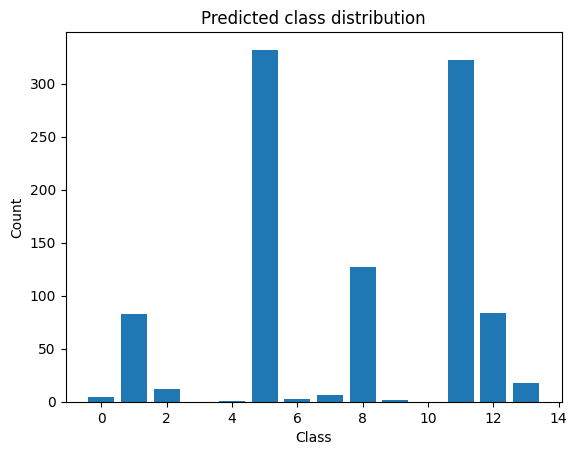

In [35]:
plt.clf()  # clear current figure
%matplotlib inline
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)

plt.bar(unique_pred, counts_pred)
plt.title("Predicted class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()